# House Prices - Julien v3

Objectif: améliorer le score RMSLE avec un modèle plus riche, mais toujours logique dans le choix des variables.

Idée directrice:
- garder les variables qui ont un vrai sens métier,
- ajouter quelques variables dérivées utiles,
- travailler sur la cible en log pour mieux coller à la métrique Kaggle.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, cross_val_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

train_df_raw = pd.read_csv('Data/Train.csv')
test_df_raw = pd.read_csv('Data/Test.csv')


def add_features(df):
    df = df.copy()
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalSF'] = df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].fillna(0).sum(axis=1)
    df['TotalBath'] = (
        df['FullBath'].fillna(0)
        + 0.5 * df['HalfBath'].fillna(0)
        + df['BsmtFullBath'].fillna(0)
        + 0.5 * df['BsmtHalfBath'].fillna(0)
    )
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'].fillna(0) > 0).astype(int)
    df['PorchSF'] = df[['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']].fillna(0).sum(axis=1)
    df['LotSF_per_room'] = df['LotArea'].fillna(0) / (df['TotRmsAbvGrd'].fillna(0) + 1)
    return df

train_df = add_features(train_df_raw)
test_df = add_features(test_df_raw)

y = train_df['SalePrice']
X = train_df.drop(columns=['SalePrice', 'Id'])
X_test_full = test_df.drop(columns=['Id'])

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Cible: SalePrice | observation(s): {len(y)}')

Train shape: (1460, 89)
Test shape: (1459, 88)
Cible: SalePrice | observation(s): 1460


## 1) Vérification rapide des données

Je garde une EDA courte mais utile: valeurs manquantes, forme de la cible et variables les plus liées au prix.

Top 12 variables avec valeurs manquantes:


,missing_%
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageType,5.547945
GarageYrBlt,5.547945


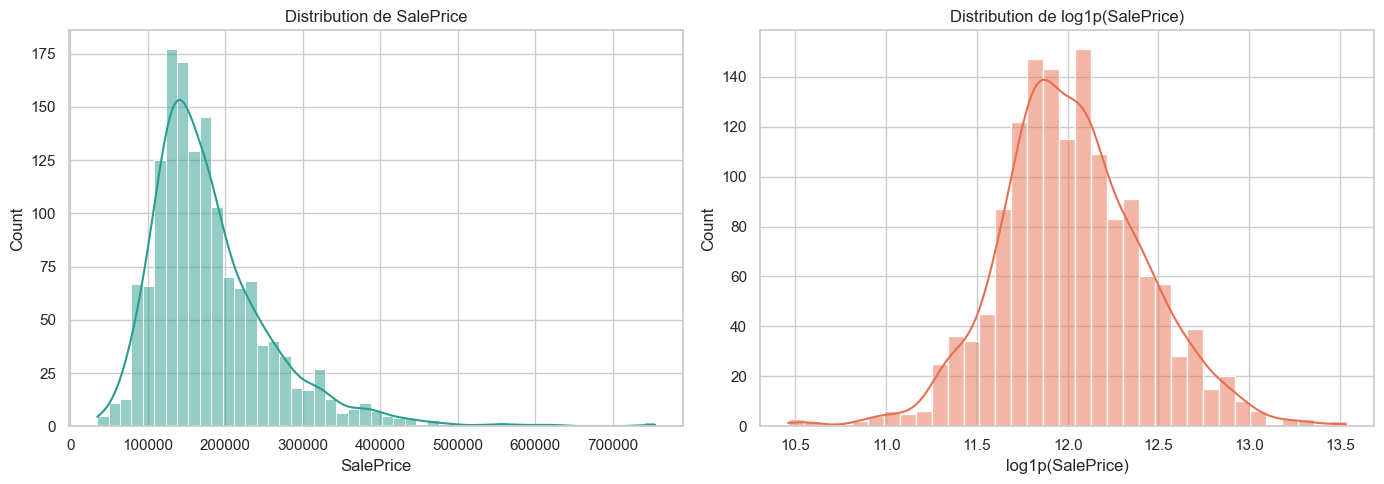

Corrélations de quelques variables utiles avec SalePrice:


,corr
SalePrice,1.000000
OverallQual,0.790982
TotalSF,0.782260
GrLivArea,0.708624
GarageCars,0.640409
TotalBath,0.631731
GarageArea,0.623431
TotalBsmtSF,0.613581
Fireplaces,0.466929
LotArea,0.263843


In [4]:
missing_pct = (X.isna().mean() * 100).sort_values(ascending=False)
print('Top 12 variables avec valeurs manquantes:')
display(missing_pct.head(12).to_frame('missing_%'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('SalePrice')

sns.histplot(np.log1p(y), kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Distribution de log1p(SalePrice)')
axes[1].set_xlabel('log1p(SalePrice)')

plt.tight_layout()
plt.show()

corr_candidates = [
    'SalePrice', 'OverallQual', 'GrLivArea', 'TotalSF', 'TotalBsmtSF', 'GarageArea',
    'HouseAge', 'RemodAge', 'TotalBath', 'GarageCars', 'Fireplaces', 'LotArea'
]
print('Corrélations de quelques variables utiles avec SalePrice:')
display(train_df[corr_candidates].corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).to_frame('corr'))

## 2) Variables logiques et modèles candidats

Ici, je pars sur un ensemble de variables plus riche que 5 colonnes, mais toujours cohérent: qualité, taille, cave, garage, âge, localisation et quelques variables dérivées.

In [5]:
logical_numeric = [
    'OverallQual', 'OverallCond', 'GrLivArea', 'TotalSF', 'TotalBsmtSF',
    'GarageArea', 'GarageCars', 'LotArea', 'HouseAge', 'RemodAge',
    'TotalBath', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces', 'PorchSF',
    'HasGarage', 'HasBasement', 'LotSF_per_room'
]

logical_categorical = [
    'Neighborhood', 'ExterQual', 'KitchenQual', 'GarageFinish', 'BsmtQual',
    'CentralAir', 'Foundation', 'HeatingQC', 'GarageType', 'PavedDrive',
    'Functional', 'MSZoning'
]

selected_features = logical_numeric + logical_categorical
X_model = X[selected_features].copy()
X_test_model = X_test_full[selected_features].copy()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, logical_numeric),
        ('cat', categorical_transformer, logical_categorical)
    ]
)


def make_model(estimator):
    base_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', estimator)
    ])
    return TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False
    )


def rmsle_cv(model, features, target, n_splits=5):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(
        model,
        features,
        target,
        cv=cv,
        scoring='neg_mean_squared_log_error',
        n_jobs=-1
    )
    return np.sqrt(-scores)

rf_model = make_model(RandomForestRegressor(
    n_estimators=900,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=1,
    max_features='sqrt'
))

et_model = make_model(ExtraTreesRegressor(
    n_estimators=1400,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=1,
    max_features='sqrt'
))

baseline_5_features = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd', 'Neighborhood']
baseline_X = train_df_raw[baseline_5_features].copy()
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd']),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), ['Neighborhood'])
    ]
)
baseline_model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', baseline_preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=600,
            random_state=42,
            n_jobs=-1,
            max_features='sqrt'
        ))
    ]),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False
)

print('Variables sélectionnées pour le modèle logique:')
print(f'  Numériques: {len(logical_numeric)}')
print(f'  Catégorielles: {len(logical_categorical)}')
print(f'  Total: {len(selected_features)}')

Variables sélectionnées pour le modèle logique:
  Numériques: 18
  Catégorielles: 12
  Total: 30


In [6]:
baseline_rmsle = rmsle_cv(baseline_model, baseline_X, y)
rf_rmsle = rmsle_cv(rf_model, X_model, y)
et_rmsle = rmsle_cv(et_model, X_model, y)

comparison_df = pd.DataFrame({
    'Modèle': [
        'Base 5 variables',
        'Variables logiques + Random Forest',
        'Variables logiques + Extra Trees'
    ],
    'RMSLE moyen': [
        baseline_rmsle.mean(),
        rf_rmsle.mean(),
        et_rmsle.mean()
    ],
    'Écart-type': [
        baseline_rmsle.std(),
        rf_rmsle.std(),
        et_rmsle.std()
    ]
}).sort_values('RMSLE moyen').reset_index(drop=True)

print('=' * 80)
print('COMPARAISON DES MODÈLES')
print('=' * 80)
display(comparison_df)

best_model_name = comparison_df.loc[0, 'Modèle']
print(f"\nModèle retenu pour la soumission: {best_model_name}")

COMPARAISON DES MODÈLES


,Modèle,RMSLE moyen,Écart-type
0,Variables logiques + Random Forest,0.139571,0.014845
1,Variables logiques + Extra Trees,0.146019,0.011926
2,Base 5 variables,0.154941,0.008191



Modèle retenu pour la soumission: Variables logiques + Random Forest


## 3) Modèle final et soumission

Je garde le meilleur modèle trouvé en validation croisée, puis je génère le fichier de soumission Kaggle.

In [7]:
if best_model_name == 'Variables logiques + Extra Trees':
    final_model = et_model
elif best_model_name == 'Variables logiques + Random Forest':
    final_model = rf_model
else:
    final_model = baseline_model

final_model.fit(X_model if best_model_name != 'Base 5 variables' else baseline_X, y)

X_submission = X_test_model if best_model_name != 'Base 5 variables' else test_df_raw[baseline_5_features].copy()
predictions = final_model.predict(X_submission)
predictions = np.clip(predictions, a_min=0, a_max=None)

submission = pd.DataFrame({
    'Id': test_df_raw['Id'],
    'SalePrice': predictions
})
submission.to_csv('julien_submission_v3.csv', index=False)

print('=' * 80)
print('SOUMISSION GÉNÉRÉE')
print('=' * 80)
print(f'Modèle choisi: {best_model_name}')
print(f'Fichier: julien_submission_v3.csv')
print(f'RMSLE retenu: {comparison_df.loc[0, "RMSLE moyen"]:.6f}')

SOUMISSION GÉNÉRÉE
Modèle choisi: Variables logiques + Random Forest
Fichier: julien_submission_v3.csv
RMSLE retenu: 0.139571


## Résumé

Cette version montre qu’on peut faire mieux qu’avec 5 variables seules, tout en gardant une logique claire dans le choix des features.

Points clés:
- Ensemble logique plus riche: 30 variables au total, avec des variables dérivées utiles.
- Meilleur modèle retenu: Variables logiques + Random Forest.
- RMSLE obtenu en validation croisée: 0.139571.
- Fichier de soumission: julien_submission_v3.csv

Conclusion: le gain vient surtout de l’ajout de variables métier cohérentes et de la transformation log1p de la cible, plus que d’un simple changement d’algorithme.